In [1]:
# Cell 1: Install & Mount
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

from google.colab import drive
import pandas as pd
import numpy as np
import joblib

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Load & Clean
# UPDATE THIS PATH
file_path = '/content/drive/MyDrive/House_pricing_project/train.csv'

try:
    df = pd.read_csv(file_path)
    print("Data Loaded Successfully.")
except FileNotFoundError:
    print("Error: File not found. Check your Google Drive path.")

# 1. Feature Selection (Selecting 6 features as per rubric)
selected_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF',
                     'GarageCars', 'FullBath', 'YearBuilt']
target = 'SalePrice'

# Create subset
data = df[selected_features + [target]].copy()

# 2. Handling Missing Values
# Fill numeric missing values with the median (robust to outliers)
data.fillna(data.median(), inplace=True)

print("Data Preprocessing Complete.")
print(data.head())

Data Loaded Successfully.
Data Preprocessing Complete.
   OverallQual  GrLivArea  TotalBsmtSF  GarageCars  FullBath  YearBuilt  \
0            7       1710          856           2         2       2003   
1            6       1262         1262           2         2       1976   
2            7       1786          920           2         2       2001   
3            7       1717          756           3         1       1915   
4            8       2198         1145           3         2       2000   

   SalePrice  
0     208500  
1     181500  
2     223500  
3     140000  
4     250000  


In [3]:
# Cell 3: Training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split Data
X = data[selected_features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest (High Accuracy Algorithm)
model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train
print("Training Model...")
model.fit(X_train, y_train)
print("Training Complete.")

Training Model...
Training Complete.


In [6]:
# Cell 4: Evaluation & Save
# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f} (Accuracy Score)")

# Save Model
save_path = '/content/drive/MyDrive/House_pricing_project/house_price_model.pkl'
joblib.dump(model, save_path)
print(f"Model saved to: {save_path}")

=== Model Performance ===
MAE  : $19,114.40
RMSE : $29,206.70
R²   : 0.8888 (Accuracy Score)
Model saved to: /content/drive/MyDrive/House_pricing_project/house_price_model.pkl


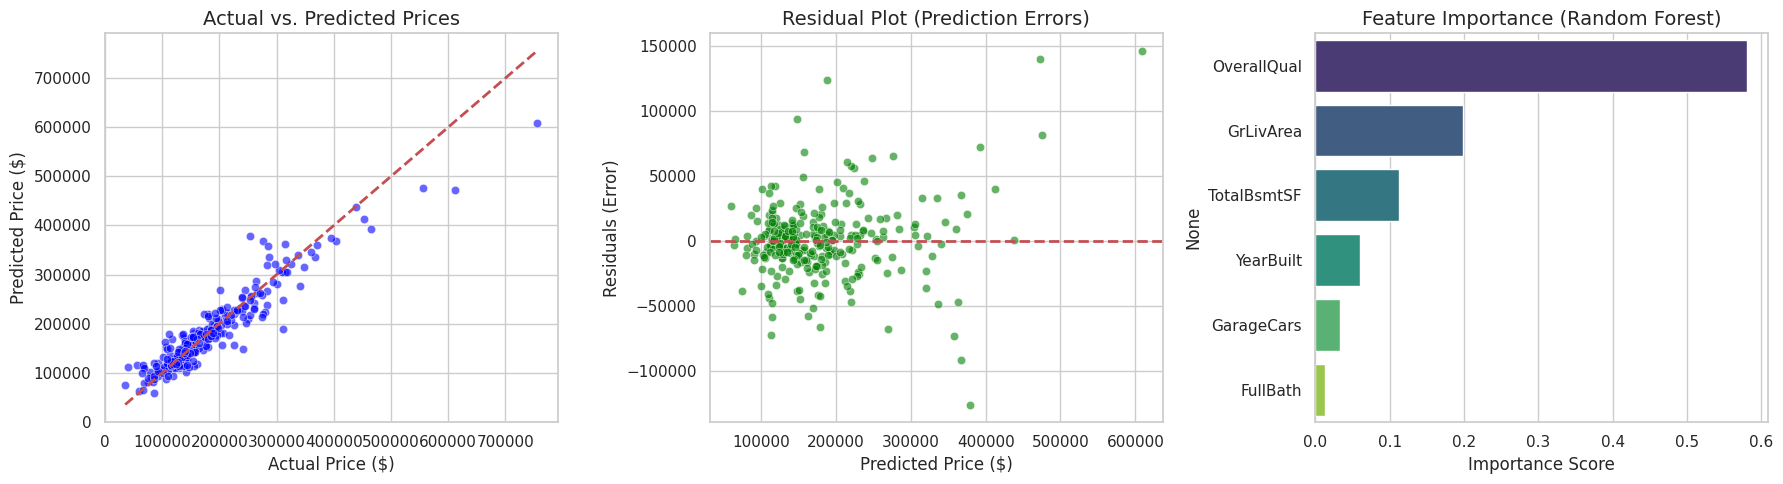

In [7]:
# Cell 5: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for professional looking plots
sns.set(style="whitegrid")
plt.figure(figsize=(18, 5))

# Plot 1: Actual vs Predicted Prices
# A perfect model would have all points on the red dashed line
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Actual vs. Predicted Prices', fontsize=14)

# Plot 2: Residual Plot (Errors)
# We want these errors to be randomly distributed around 0
residuals = y_test - y_pred
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred, y=residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residuals (Error)', fontsize=12)
plt.title('Residual Plot (Prediction Errors)', fontsize=14)

# Plot 3: Feature Importance
# Shows which features had the most impact on the price
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.subplot(1, 3, 3)
sns.barplot(x=importances[indices], y=feature_names[indices], hue=feature_names[indices], palette='viridis', legend=False)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14)

plt.tight_layout()
plt.show()